In [1]:
import torch, transformers, cv2, pandas as pd
from PIL import Image

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Transformers:", transformers.__version__)
print("OpenCV:", cv2.__version__)
print("✅ All good — ready to build!")

c:\Projects\medocr\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cpu
GPU available: False
Transformers: 5.5.4
OpenCV: 4.13.0
✅ All good — ready to build!


In [2]:
import os

folders = [
    "data/iam/images",
    "data/iam/ascii",
    "data/gnhk",
    "data/synthetic/images",
    "fonts"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created: {folder}")

✅ Created: data/iam/images
✅ Created: data/iam/ascii
✅ Created: data/gnhk
✅ Created: data/synthetic/images
✅ Created: fonts


In [3]:
import requests, os

os.makedirs("fonts", exist_ok=True)

font_urls = {
    "Caveat-Regular.ttf":      "https://fonts.gstatic.com/s/caveat/v18/WnznHAc5bAfYB2QRah7pcpNvOx-pjfB9eIWpZA.ttf",
    "IndieFlower-Regular.ttf": "https://fonts.gstatic.com/s/indieflower/v21/m8JVjfNVeKWVnh3QMuKkFcZlbkGG1dKEDw.ttf",
    "PatrickHand-Regular.ttf": "https://fonts.gstatic.com/s/patrickhand/v20/LDI1apSQOAYtSuYWp8ZhfYe8XsLLgy8.ttf",
}

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

for filename, url in font_urls.items():
    dest = f"fonts/{filename}"
    if not os.path.exists(dest):
        try:
            r = requests.get(url, headers=headers, timeout=15)
            r.raise_for_status()
            with open(dest, "wb") as f:
                f.write(r.content)
            print(f"✅ Saved: {filename}")
        except Exception as e:
            print(f"❌ Failed: {filename} — {e}")
    else:
        print(f"✅ Already exists: {filename}")

✅ Already exists: Caveat-Regular.ttf
✅ Already exists: IndieFlower-Regular.ttf
✅ Already exists: PatrickHand-Regular.ttf


In [4]:
from PIL import Image, ImageDraw, ImageFont
import pandas as pd, os, random

os.makedirs("data/synthetic/images", exist_ok=True)

medical_lines = [
    "Tab. Metformin 500mg BD x 30d",
    "Tab. Paracetamol 650mg SOS",
    "Inj. Insulin 10 units SC stat",
    "Syp. Amoxicillin 250mg/5ml TID",
    "Cap. Omeprazole 20mg OD ac",
    "Tab. Atorvastatin 10mg HS",
    "Tab. Azithromycin 500mg OD x 3d",
    "Tab. Amlodipine 5mg OD",
    "Tab. Metoprolol 50mg BD",
    "Inj. Ceftriaxone 1g IV BD",
    "Tab. Pantoprazole 40mg OD ac",
    "Syp. Paracetamol 120mg/5ml TID",
    "Tab. Cetirizine 10mg OD HS",
    "Cap. Amoxicillin 500mg TID x 5d",
    "Tab. Diclofenac 50mg BD pc",
    "Tab. Losartan 50mg OD",
    "Tab. Glimepiride 1mg OD ac",
    "Tab. Aspirin 75mg OD pc",
    "Inj. Ranitidine 50mg IV BD",
    "Tab. Montelukast 10mg OD HS",
]

# Load available fonts
font_dir = "fonts"
font_files = [os.path.join(font_dir, f) for f in os.listdir(font_dir) if f.endswith(".ttf")]

if not font_files:
    print("⚠️ No fonts found — using default font")
else:
    print(f"✅ Found {len(font_files)} fonts: {font_files}")

def make_image(text, font_files):
    w, h = 420, 48
    bg = (random.randint(240, 255), random.randint(238, 252), random.randint(225, 245))
    img = Image.new("RGB", (w, h), color=bg)
    draw = ImageDraw.Draw(img)

    try:
        font_path = random.choice(font_files) if font_files else None
        font_size = random.randint(18, 26)
        font = ImageFont.truetype(font_path, font_size) if font_path else ImageFont.load_default()
    except:
        font = ImageFont.load_default()

    ink = (
        random.randint(0, 40),
        random.randint(0, 40),
        random.randint(80, 140)
    )

    x = random.randint(6, 14)
    y = random.randint(6, 16)
    draw.text((x, y), text, font=font, fill=ink)

    angle = random.uniform(-3, 3)
    img = img.rotate(angle, fillcolor=bg)

    return img

records = []
total = 1000
print(f"\nGenerating {total} synthetic medical images...")

for i in range(total):
    label = random.choice(medical_lines)
    img   = make_image(label, font_files)
    path  = f"data/synthetic/images/synth_{i:05d}.png"
    img.save(path)
    records.append({"image_path": path, "transcription": label, "source": "synthetic"})
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{total} done...")

df_synth = pd.DataFrame(records)
df_synth.to_csv("data/labels_synthetic.csv", index=False)
print(f"\n✅ Done! {len(df_synth)} images saved to data/synthetic/images/")
print(df_synth.head())

✅ Found 3 fonts: ['fonts\\Caveat-Regular.ttf', 'fonts\\IndieFlower-Regular.ttf', 'fonts\\PatrickHand-Regular.ttf']

Generating 1000 synthetic medical images...
  200/1000 done...
  400/1000 done...
  600/1000 done...
  800/1000 done...
  1000/1000 done...

✅ Done! 1000 images saved to data/synthetic/images/
                              image_path                    transcription  \
0  data/synthetic/images/synth_00000.png  Cap. Amoxicillin 500mg TID x 5d   
1  data/synthetic/images/synth_00001.png       Cap. Omeprazole 20mg OD ac   
2  data/synthetic/images/synth_00002.png      Tab. Montelukast 10mg OD HS   
3  data/synthetic/images/synth_00003.png   Syp. Paracetamol 120mg/5ml TID   
4  data/synthetic/images/synth_00004.png       Tab. Diclofenac 50mg BD pc   

      source  
0  synthetic  
1  synthetic  
2  synthetic  
3  synthetic  
4  synthetic  


In [5]:
import os, pandas as pd

def parse_iam_words(words_txt_path, images_root):
    records = []
    errors  = 0
    with open(words_txt_path, "r") as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split(" ")
            if len(parts) < 9:
                continue
            word_id      = parts[0]
            seg_result   = parts[1]
            transcription = parts[-1]
            id_parts     = word_id.split("-")
            if len(id_parts) < 3:
                continue
            img_path = os.path.join(
                images_root,
                id_parts[0],
                f"{id_parts[0]}-{id_parts[1]}",
                f"{word_id}.png"
            )
            if seg_result == "ok" and os.path.exists(img_path):
                records.append({
                    "image_path":    img_path,
                    "transcription": transcription,
                    "source":        "iam"
                })
            else:
                errors += 1
    print(f"✅ Loaded: {len(records)} | ⚠️ Skipped: {errors}")
    return pd.DataFrame(records)

df_iam = parse_iam_words(
    "data/iam/iam_words/words.txt",
    "data/iam/iam_words/words"
)
df_iam.to_csv("data/labels_iam.csv", index=False)
print(df_iam.head())

✅ Loaded: 38305 | ⚠️ Skipped: 6259
                                          image_path transcription source
0  data/iam/iam_words/words\a01\a01-000u\a01-000u...             A    iam
1  data/iam/iam_words/words\a01\a01-000u\a01-000u...          MOVE    iam
2  data/iam/iam_words/words\a01\a01-000u\a01-000u...            to    iam
3  data/iam/iam_words/words\a01\a01-000u\a01-000u...          stop    iam
4  data/iam/iam_words/words\a01\a01-000u\a01-000u...           Mr.    iam


In [6]:
from sklearn.model_selection import train_test_split
import pandas as pd

df_iam   = pd.read_csv("data/labels_iam.csv")
df_synth = pd.read_csv("data/labels_synthetic.csv")

df_all = pd.concat([df_iam, df_synth], ignore_index=True)
df_all = df_all[df_all["transcription"].str.len() > 1].reset_index(drop=True)

print(f"Total: {len(df_all)}")
print(df_all["source"].value_counts())

df_train, df_temp = train_test_split(df_all, test_size=0.2, random_state=42)
df_val,   df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

df_train = df_train.copy(); df_train["split"] = "train"
df_val   = df_val.copy();   df_val["split"]   = "val"
df_test  = df_test.copy();  df_test["split"]  = "test"

df_final = pd.concat([df_train, df_val, df_test])
df_final.to_csv("data/labels_final.csv", index=False)
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print("✅ Saved to data/labels_final.csv")

Total: 34273
source
iam          33273
synthetic     1000
Name: count, dtype: int64
Train: 27418 | Val: 3427 | Test: 3428
✅ Saved to data/labels_final.csv


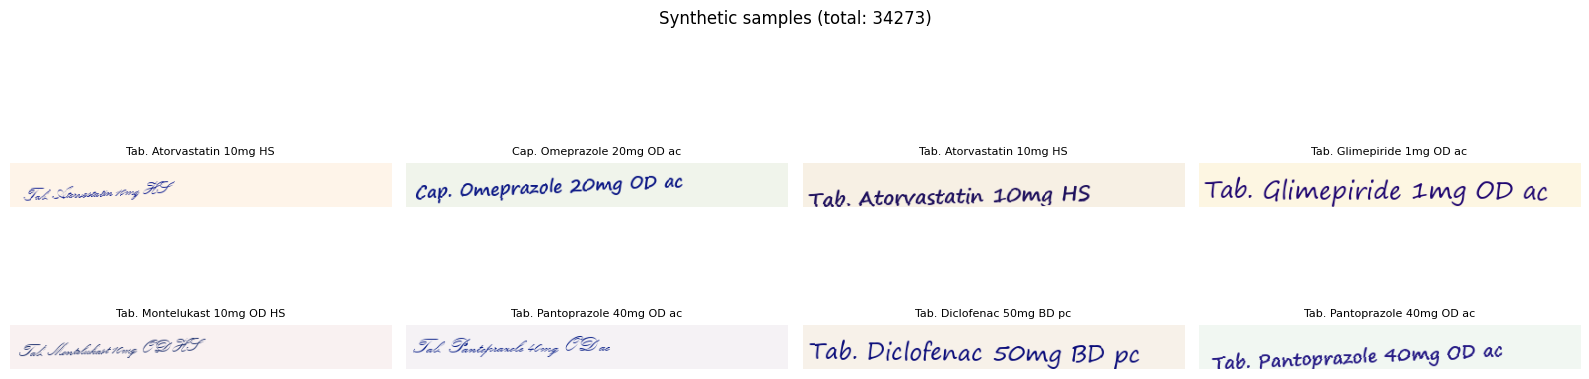

✅ Done!


In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

df      = pd.read_csv("data/labels_final.csv")
samples = df[df["source"] == "synthetic"].sample(8)

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(row["transcription"][:30], fontsize=8)
    ax.axis("off")

plt.suptitle(f"Synthetic samples (total: {len(df)})", fontsize=12)
plt.tight_layout()
plt.savefig("data/sample_check.png", dpi=150)
plt.show()
print("✅ Done!")